In [205]:
import pandas as pd
import datetime as dt
import numpy as np
import matplotlib.pyplot as plt
import os 
import torch 
import torch.nn as nn
import torch.optim as optim


from matplotlib.dates import DateFormatter, YearLocator, MonthLocator
from vnstock import Vnstock
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import root_mean_squared_error

In [206]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(device)

cpu


In [207]:
#Lấy mốc thời gia bắt đầu lấy dữ liệu do người dùng nhập vào
start = input("Nhập ngày bắt đầu lấy dữ liệu (yyyy-mm-dd): ")

#Tự động lấy ngày hiện tại làm ngày kết thúc
end = dt.datetime.now().strftime('%Y-%m-%d')

In [208]:
#Nhập mã cổ phiếu cần lấy dữ liệu
stock_symbol = input("Nhập mã cổ phiếu (ví dụ: VIC, VHM, VCB,...): ")

#Lấy dữ liệu cổ phiếu từ vnstock
try :
    stock = Vnstock().stock(symbol=stock_symbol, source='VCI')
    stock_data = stock.quote.history(start=start, end=end)
except ValueError as e:
    print(f"{e}: Vui lòng kiểm tra lại mã cổ phiếu hoặc ngày tháng.")
    exit()

#Đẩy dữ liệu vào DataFrame và in dữ liệu 5 dòng đầu và cuối
df = pd.DataFrame(stock_data)
print(df.head())
print(df.tail())

        time   open   high    low  close   volume
0 2023-11-24  20.68  20.75  20.30  20.68  3531149
1 2023-11-27  20.65  21.10  20.65  20.92  2797486
2 2023-11-28  20.92  21.25  20.80  21.20  2475131
3 2023-11-29  21.20  21.32  21.15  21.28  2054168
4 2023-11-30  21.25  21.42  20.88  20.88  3468773
          time   open   high    low  close    volume
506 2025-12-05  142.8  142.8  139.4  142.8   7036892
507 2025-12-08  152.0  152.7  149.1  152.7   4619098
508 2025-12-09  163.3  163.3  153.0  160.0  12899048
509 2025-12-10  160.0  160.0  148.8  148.8   6630242
510 2025-12-11  143.0  147.6  138.4  145.5   4579500


In [209]:
df['H-L'] = df['high'] - df['low']
df['O-C'] = df['open'] - df['close']

ma_20 = 20
ma_50 = 50
ma_200 = 200

df[f'SMA_{ma_20}'] = df['close'].rolling(window=ma_20).mean()
df[f'SMA_{ma_50}'] = df['close'].rolling(window=ma_50).mean()
df[f'SMA_{ma_200}'] = df['close'].rolling(window=ma_200).mean()

df[f'SD_{ma_50}'] = df['close'].rolling(window=ma_50).std()
df[f'SD_{ma_200}'] = df['close'].rolling(window=ma_200).std()

#RSI (Relative Strength Index)
delta = df['close'].diff()
gain = (delta.where(delta > 0, 0)).rolling(window=14).mean()
loss = (-delta.where(delta < 0, 0)).rolling(window=14).mean()
rs = gain / loss
df['RSI'] = 100 - (100 / (1 + rs))

df.dropna(inplace=True)
print(df.head())

          time   open   high    low  close   volume   H-L   O-C   SMA_20  \
199 2024-09-16  21.35  21.80  21.02  21.02  2007657  0.78  0.33  21.5065   
200 2024-09-17  21.02  21.60  21.02  21.45  2239274  0.58 -0.43  21.5500   
201 2024-09-18  21.45  21.65  21.32  21.32  2749621  0.33  0.13  21.5870   
202 2024-09-19  21.40  21.60  21.35  21.45  2241321  0.25 -0.05  21.6170   
203 2024-09-20  21.50  21.82  21.15  21.15  3928381  0.67  0.35  21.6285   

      SMA_50   SMA_200     SD_50    SD_200        RSI  
199  20.9738  21.83290  0.641888  1.034175  52.764977  
200  20.9888  21.83675  0.644118  1.031290  54.138702  
201  21.0112  21.83875  0.635545  1.029890  30.351438  
202  21.0322  21.84000  0.632276  1.029263  37.113402  
203  21.0492  21.83935  0.623554  1.029659  34.726688  


In [210]:
#Đổi tên cột để dễ hiểu
df.rename(columns={'time': 'yyyy-mm-dd', 'open': 'Giá mở cửa', 'high': 'Giá trần', 'low': 'Giá sàn', 'close': 'Giá đóng cửa', 'volume': 'Khối lượng giao dịch'}, inplace=True)

# Chuyển cột ngày sang kiểu datetime
df["yyyy-mm-dd"] = pd.to_datetime(df["yyyy-mm-dd"], errors="coerce")

# Chuyển các cột số sang float
numeric_cols = ["Giá mở cửa", "Giá trần", "Giá sàn", "Giá đóng cửa","Khối lượng giao dịch", "H-L", "O-C", "SMA_20", "SMA_50", "SMA_200", "SD_50", "SD_200", "RSI"]

df[numeric_cols] = df[numeric_cols].apply(pd.to_numeric, errors="coerce")

print(df.head())
print(df.tail())

    yyyy-mm-dd  Giá mở cửa  Giá trần  Giá sàn  Giá đóng cửa  \
199 2024-09-16       21.35     21.80    21.02         21.02   
200 2024-09-17       21.02     21.60    21.02         21.45   
201 2024-09-18       21.45     21.65    21.32         21.32   
202 2024-09-19       21.40     21.60    21.35         21.45   
203 2024-09-20       21.50     21.82    21.15         21.15   

     Khối lượng giao dịch   H-L   O-C   SMA_20   SMA_50   SMA_200     SD_50  \
199               2007657  0.78  0.33  21.5065  20.9738  21.83290  0.641888   
200               2239274  0.58 -0.43  21.5500  20.9888  21.83675  0.644118   
201               2749621  0.33  0.13  21.5870  21.0112  21.83875  0.635545   
202               2241321  0.25 -0.05  21.6170  21.0322  21.84000  0.632276   
203               3928381  0.67  0.35  21.6285  21.0492  21.83935  0.623554   

       SD_200        RSI  
199  1.034175  52.764977  
200  1.031290  54.138702  
201  1.029890  30.351438  
202  1.029263  37.113402  
203  1.0296

In [211]:
#Tạo thư mục để lưu trữ lịch sử truy xuất nếu chưa tồn tại
folder_name = "Lịch sử truy xuất"

if not os.path.exists(folder_name):
    os.makedirs(folder_name)
    
#Lưu dữ liệu vào file CSV
file_path = os.path.join(folder_name, f"Cổ_phiếu_{stock_symbol}.csv")
df.to_csv(file_path, index=False, encoding='utf-8-sig')

print(f"Đã lưu file tại: {file_path}")

Đã lưu file tại: Lịch sử truy xuất/Cổ_phiếu_VIC.csv


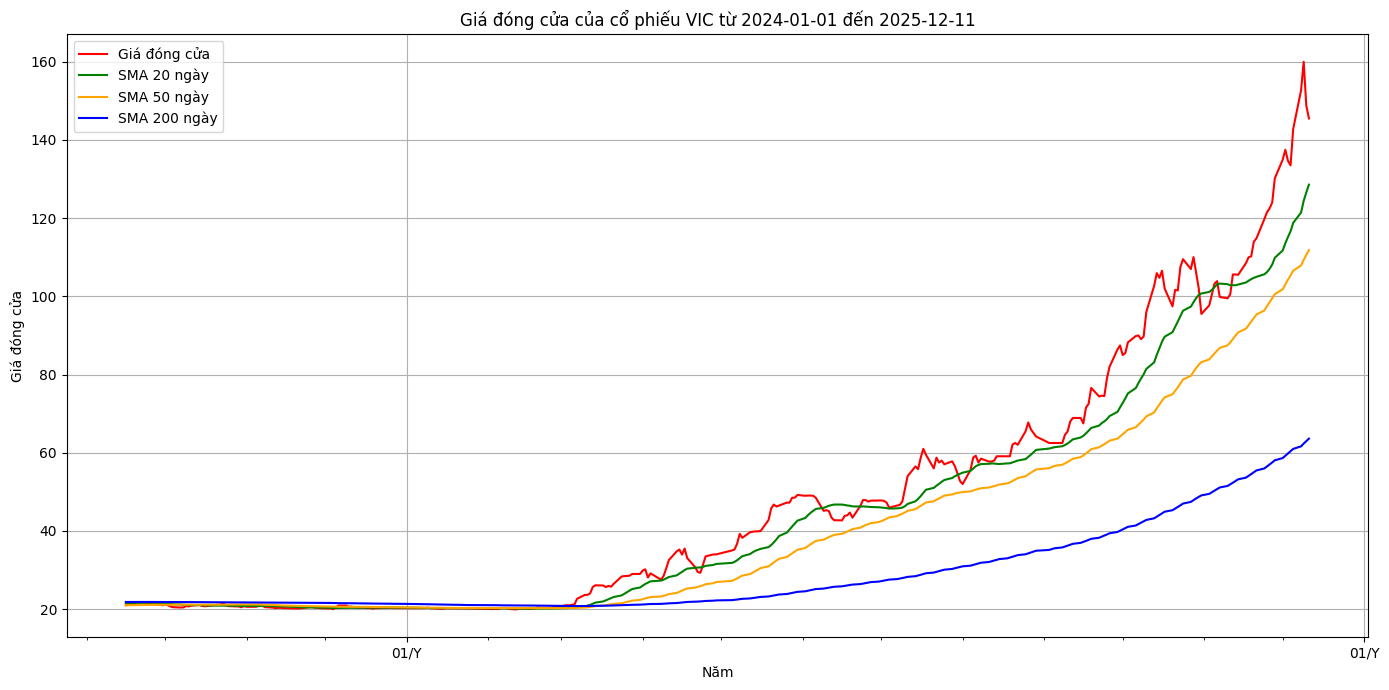

In [212]:
# Tạo đồ thị giá đóng cửa qua các năm và thêm đường trung bình động 20, 50 và 200 ngày
plt.figure(figsize=(14,7))
plt.plot(df['yyyy-mm-dd'], df['Giá đóng cửa'], label='Giá đóng cửa', color='red')
plt.plot(df['yyyy-mm-dd'], df[f'SMA_{ma_20}'], label=f'SMA {ma_20} ngày', color='green')
plt.plot(df['yyyy-mm-dd'], df[f'SMA_{ma_50}'], label=f'SMA {ma_50} ngày', color='orange')
plt.plot(df['yyyy-mm-dd'], df[f'SMA_{ma_200}'], label=f'SMA {ma_200} ngày', color='blue')
plt.title(f'Giá đóng cửa của cổ phiếu {stock_symbol} từ {start} đến {end}')
plt.xlabel('Năm')
plt.ylabel('Giá đóng cửa')
plt.legend(loc='best')

# Định dạng đồ thị hiển thị các ngày tháng theo năm tháng
years = YearLocator()   # Định vị các năm
yearsFmt = DateFormatter('%m/Y')  # Định dạng hiển thị năm
months = MonthLocator()  # Định vị các tháng
monthsFmt = DateFormatter('%m/%Y')  # Định dạng hiển thị tháng

plt.gca().xaxis.set_major_locator(years)
plt.gca().xaxis.set_major_formatter(yearsFmt)
plt.gca().xaxis.set_minor_locator(months)
# plt.gca().xaxis.set_minor_formatter(monthsFmt)

plt.tight_layout()
plt.grid()
plt.show()

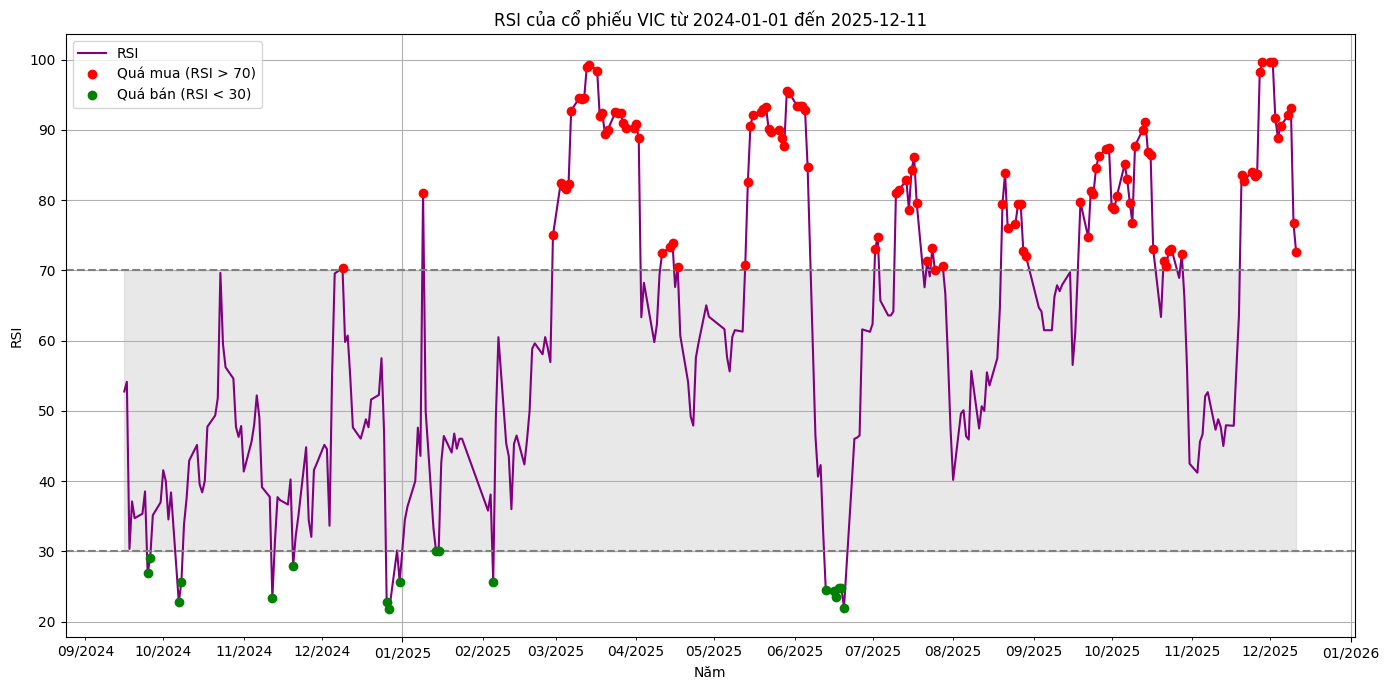

In [213]:
# Tạo thêm biểu đồ hiển thị RSI 
plt.figure(figsize=(14,7))
plt.plot(df['yyyy-mm-dd'], df['RSI'], label='RSI', color='purple')

# Vẽ các đường ngưỡng 70 và 30
plt.axhline(70, color='gray', linestyle='--')
plt.axhline(30, color='gray', linestyle='--')
# Tô màu vùng quá mua và quá bán
plt.fill_between(df['yyyy-mm-dd'], 30, 70, color='lightgray', alpha=0.5)

# RSI vượt ngưỡng 70 là màu đỏ, dưới 30 là màu xanh lá 
overbought = df['RSI'] > 70
oversold = df['RSI'] < 30
plt.plot(df['yyyy-mm-dd'][overbought], df['RSI'][overbought], 'ro', label='Quá mua (RSI > 70)')
plt.plot(df['yyyy-mm-dd'][oversold], df['RSI'][oversold], 'go', label='Quá bán (RSI < 30)')

# Thêm tiêu đề và nhãn trục
plt.title(f'RSI của cổ phiếu {stock_symbol} từ {start} đến {end}')
plt.xlabel('Năm')
plt.ylabel('RSI')
plt.legend(loc='best')

# Định dạng đồ thị hiển thị các ngày tháng theo năm tháng
years = YearLocator()   # Định vị các năm
yearsFmt = DateFormatter('%m/%Y')  # Định dạng hiển thị năm
months = MonthLocator()  # Định vị các tháng
monthsFmt = DateFormatter('%m/%Y')  # Định dạng hiển thị tháng
plt.gca().xaxis.set_major_locator(years)
plt.gca().xaxis.set_major_formatter(yearsFmt)
plt.gca().xaxis.set_minor_locator(months)
plt.gca().xaxis.set_minor_formatter(monthsFmt)
plt.tight_layout()
plt.grid()
plt.show()


In [214]:
class PredictionModel(nn.Module):
    def __init__(self, input_size, hidden_size, num_layers, output_size):
        super(PredictionModel, self).__init__()
        self.hidden_size = hidden_size
        self.num_layers = num_layers
        self.lstm = nn.LSTM(input_size, hidden_size, num_layers, batch_first=True)
        self.fc = nn.Linear(hidden_size, output_size)

    def forward(self, x):
        h0 = torch.zeros(self.num_layers, x.size(0), self.hidden_size).to(device)
        c0 = torch.zeros(self.num_layers, x.size(0), self.hidden_size).to(device)
        out, _ = self.lstm(x, (h0, c0))
        out = self.fc(out[:, -1, :])
        return out

## Chuẩn bị dữ liệu: Chọn các tính năng (features) và nhãn (labels) từ DataFrame của bạn. Chia dữ liệu thành tập huấn luyện và tập kiểm
## Tạo mô hình và định nghĩa tham số
model = PredictionModel(input_size, hidden_size, num_layers, output_size).to(device)

## Định nghĩa hàm mất mát và bộ tối ưu
criterion = nn.MSELoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

## Chuẩn bị dữ liệu (ví dụ đơn giản)
## Dữ liệu giá cổ phiếu trong một mảng numpy
data = df['Giá đóng cửa'].values.astype(float)
scaler = StandardScaler()
data = scaler.fit_transform(data.reshape(-1, 1))
## Tạo các chuỗi thời gian cho LSTM
def create_sequences(data, seq_length):
    xs = []
    ys = []
    for i in range(len(data)-seq_length):
        x = data[i:(i+seq_length)]
        y = data[i+seq_length]
        xs.append(x)
        ys.append(y)
    return np.array(xs), np.array(ys)
x_train, y_train = create_sequences(data, seq_length)
## Chuyển đổi dữ liệu sang tensor
x_train = torch.FloatTensor(x_train).to(device)
y_train = torch.FloatTensor(y_train).to(device)
## Huấn luyện mô hình
num_epochs = 100
for epoch in range(num_epochs):
    model.train()
    outputs = model(x_train)
    optimizer.zero_grad()
    loss = criterion(outputs, y_train)
    loss.backward()
    optimizer.step()
    if (epoch+1) % 10 == 0:
        print(f'Epoch [{epoch+1}/{num_epochs}], Loss: {loss.item():.4f}')
## Lưu mô hình đã huấn luyện
model_path = os.path.join(folder_name, f'model_{stock_symbol}.pth')
torch.save(model.state_dict(), model_path)
print(f'Model saved to {model_path}')

## Dự đoán giá cổ phiếu
model.eval()
with torch.no_grad():
    y_train_pred = model(x_train)
## Chuyển đổi dự đoán về dạng ban đầu
y_train_pred = scaler.inverse_transform(y_train_pred.cpu().numpy())
y_train = scaler.inverse_transform(y_train.cpu().numpy())
## Tính toán RMSE
rmse = np.sqrt(root_mean_squared_error(y_train, y_train_pred))
print(f'RMSE: {rmse:.4f}')

## Vẽ đồ thị kết quả dự đoán
plt.figure(figsize=(14,7))
plt.plot(y_train, label='Giá thực tế', color='blue')
plt.plot(y_train_pred, label='Giá dự đoán', color='red')
plt.title(f'Dự đoán giá cổ phiếu {stock_symbol} bằng LSTM')
plt.xlabel('Thời gian')
plt.ylabel('Giá cổ phiếu')
plt.legend()
plt.grid()
plt.show()
    

In [215]:
# Tạo mô hình
model = PredictionModel(input_size = 1, hidden_size = 32, num_layers = 2, output_size = 1).to(device)

In [216]:
# Định nghĩa hàm mất mát và bộ tối ưu
criterion = nn.MSELoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

In [217]:
# Chuẩn bị dữ liệu
# Dữ liệu giá cổ phiếu trong một mảng numpy
data = df['Giá đóng cửa'].values.astype(float)
scaler = StandardScaler()
data = scaler.fit_transform(data.reshape(-1, 1))

In [218]:
# Tạo các chuỗi thời gian cho LSTM
seq_length = 30
def create_sequences(data, seq_length):
    xs = []
    ys = []
    for i in range(len(data)-seq_length):
        x = data[i:(i+seq_length)]
        y = data[i+seq_length]
        xs.append(x)
        ys.append(y)
    return np.array(xs), np.array(ys)
# Định nghĩa độ dài chuỗi đầu vào cho LSTM
x_train, y_train = create_sequences(data, seq_length)
dates_train = df['yyyy-mm-dd'][seq_length:]


In [219]:
#Chuyển đổi dữ liệu sang tensor
x_train = torch.FloatTensor(x_train).to(device)
y_train = torch.FloatTensor(y_train).to(device)

In [220]:
# Huấn luyện mô hình
num_epochs = 100
for epoch in range(num_epochs):
    model.train()
    outputs = model(x_train)
    optimizer.zero_grad()
    loss = criterion(outputs, y_train)
    loss.backward()
    optimizer.step()
    if (epoch+1) % 10 == 0:
        print(f'Epoch [{epoch+1}/{num_epochs}], Loss: {loss.item():.4f}')

Epoch [10/100], Loss: 0.9639
Epoch [20/100], Loss: 0.7631
Epoch [30/100], Loss: 0.2583
Epoch [40/100], Loss: 0.1187
Epoch [50/100], Loss: 0.0865
Epoch [60/100], Loss: 0.0700
Epoch [70/100], Loss: 0.0506
Epoch [80/100], Loss: 0.0419
Epoch [90/100], Loss: 0.0346
Epoch [100/100], Loss: 0.0291


In [221]:
# Dự đoán giá cổ phiếu
model.eval()
with torch.no_grad():
    y_train_pred = model(x_train)

In [222]:
# Chuyển đổi dự đoán về dạng ban đầu
y_train_pred = scaler.inverse_transform(y_train_pred.cpu().numpy())
y_train = scaler.inverse_transform(y_train.cpu().numpy())

In [223]:
# Tính toán RMSE
rmse = np.sqrt(root_mean_squared_error(y_train, y_train_pred))
print(f'RMSE: {rmse:.4f}')

RMSE: 2.3686


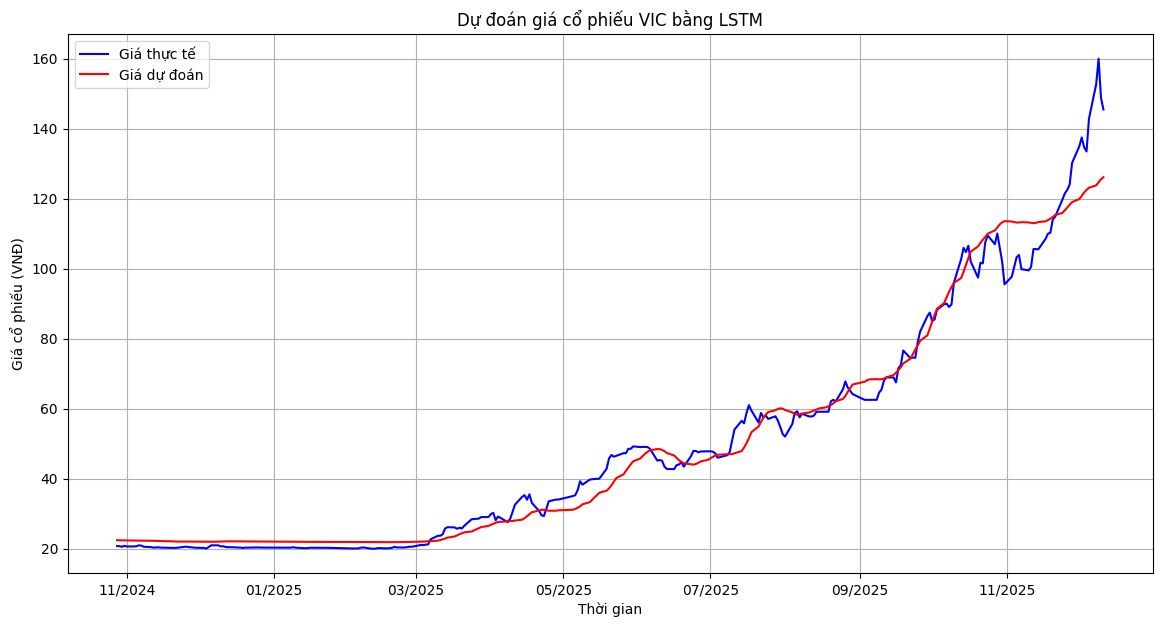

In [224]:
# Vẽ đồ thị kết quả dự đoán
plt.figure(figsize=(14,7))
plt.plot(dates_train, y_train, label='Giá thực tế', color='blue')
plt.plot(dates_train, y_train_pred, label='Giá dự đoán', color='red')
plt.title(f'Dự đoán giá cổ phiếu {stock_symbol} bằng LSTM')
plt.xlabel('Thời gian')
plt.ylabel('Giá cổ phiếu (VNĐ)')
plt.legend()
plt.grid()

# Định dạng trục x hiển thị tháng-năm
plt.gca().xaxis.set_major_formatter(DateFormatter('%m/%Y'))